LABEL ENCODER AND STANDARD SCALER

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('bank-additional-full.csv',sep=';')

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.isnull().sum()

age               4
job               5
marital           5
education         5
default           4
housing           3
loan              4
contact           4
month             3
day_of_week       3
duration          3
campaign          3
pdays             3
previous          3
poutcome          5
emp.var.rate      3
cons.price.idx    4
cons.conf.idx     3
euribor3m         3
nr.employed       3
y                 3
dtype: int64

In [5]:
df=df.dropna()

In [6]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(13)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.duplicated().sum()

np.int64(0)

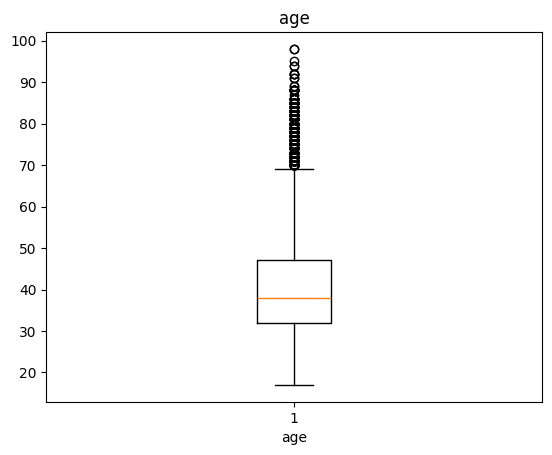

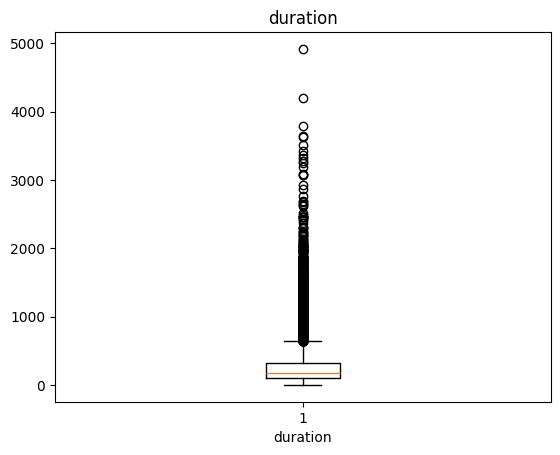

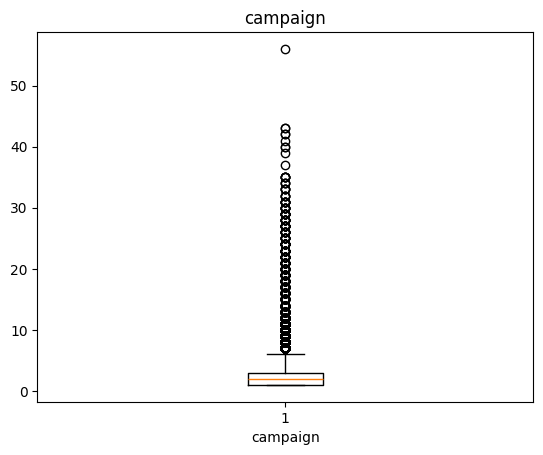

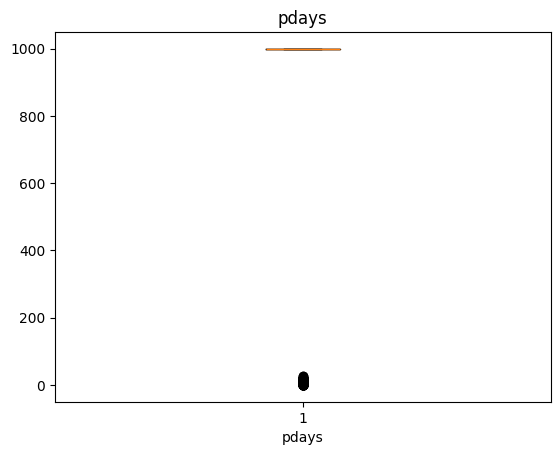

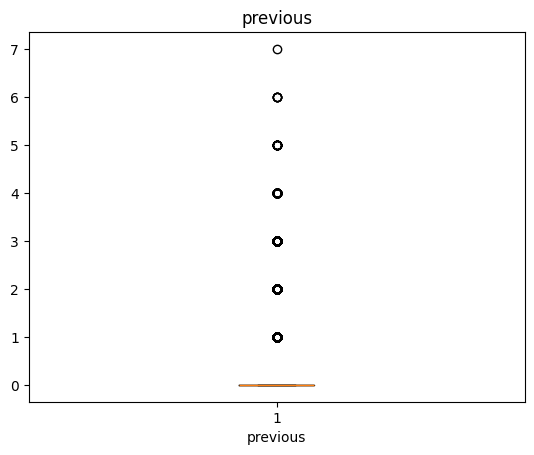

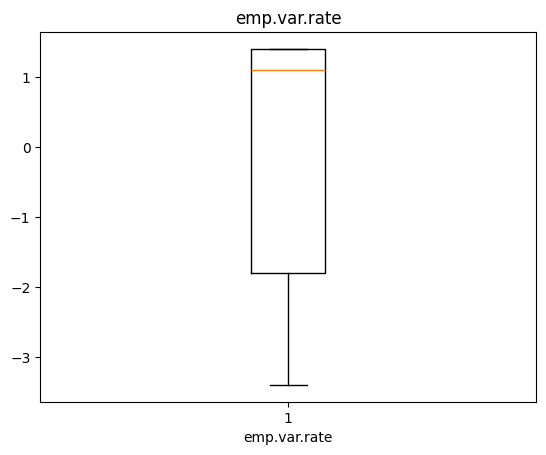

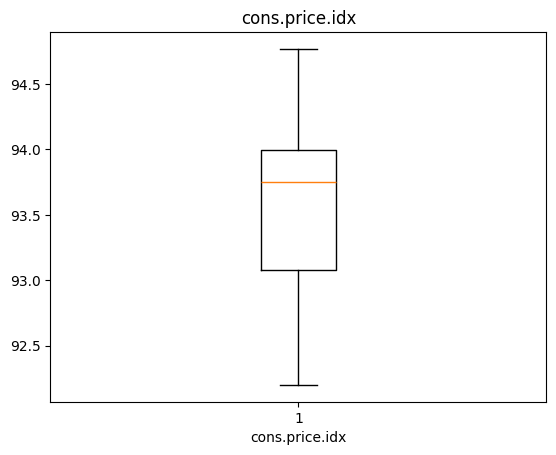

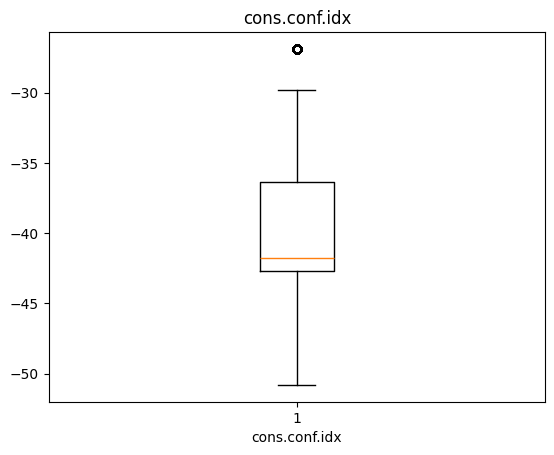

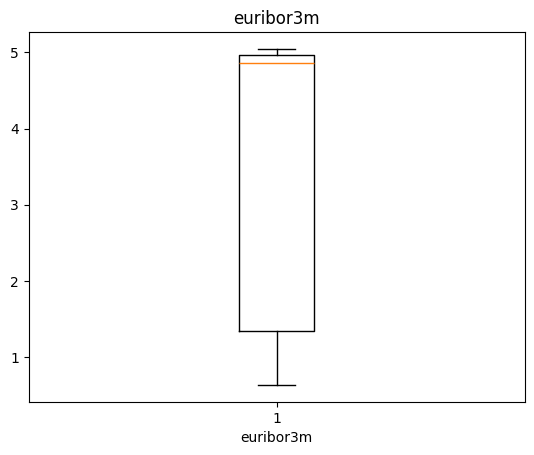

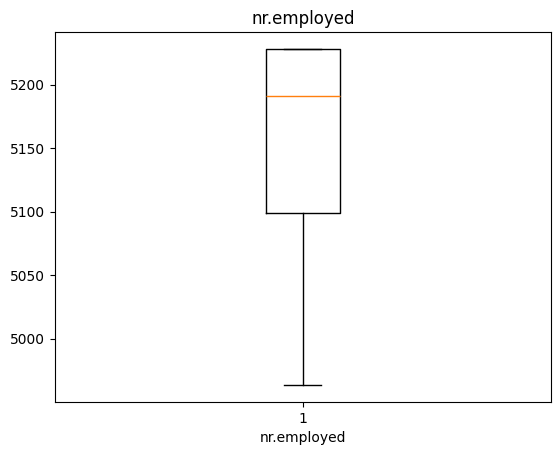

In [10]:
for col in df.columns:
    if df[col].dtype == "float64":     #df[i].dtypes=="int64" or df[i].dtypes=="float64"
        try:
            plt.boxplot(df[col].dropna())
            plt.title(col)
            plt.xlabel(col)
            plt.show()
        except Exception as e:
            print(f"Error in column: {col}")
            print(e)

In [11]:
# Outliers
Q1 = df.age.quantile(0.25)
Q3 = df.age.quantile(0.75)
IQR = Q3 - Q1
LL=Q1 - 1.5 * IQR
UL=Q3 + 1.5 * IQR

df=df[(df.age >= LL) & (df.age <= UL)]

In [12]:
Q1 = df.duration.quantile(0.25)
Q3 = df.duration.quantile(0.75)
IQR = Q3 - Q1
LL=Q1 - 1.5 * IQR
UL=Q3 + 1.5 * IQR

In [13]:
Q1= df.campaign.quantile(0.25)
Q3= df.campaign.quantile(0.75)
IQR = Q3 - Q1
LL=Q1 - 1.5 * IQR
UL=Q3 + 1.5 * IQR

In [14]:
Q1 = df.pdays.quantile(0.25)
Q3 = df.pdays.quantile(0.75)
IQR = Q3 - Q1
LL=Q1 - 1.5 * IQR
UL=Q3 + 1.5 * IQR

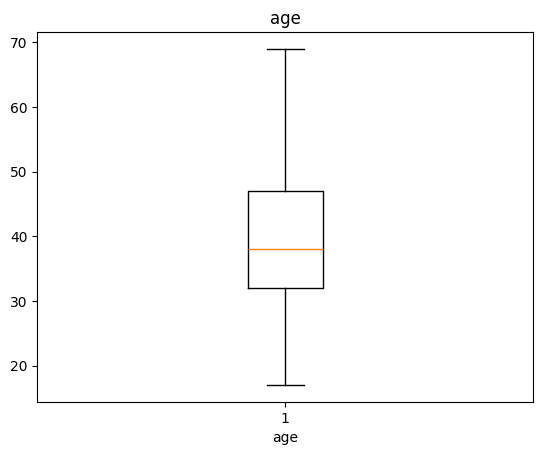

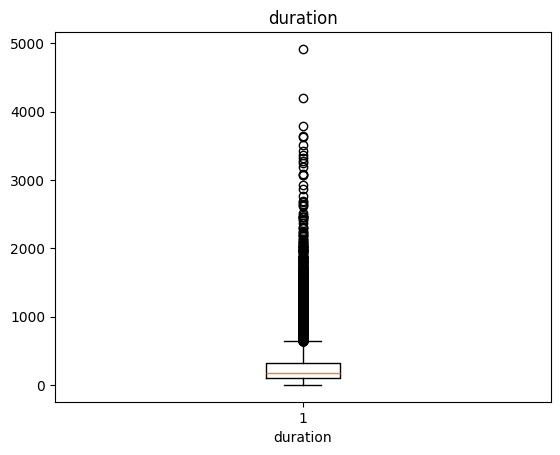

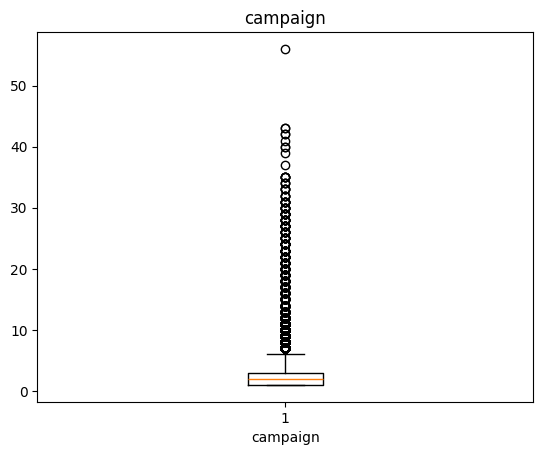

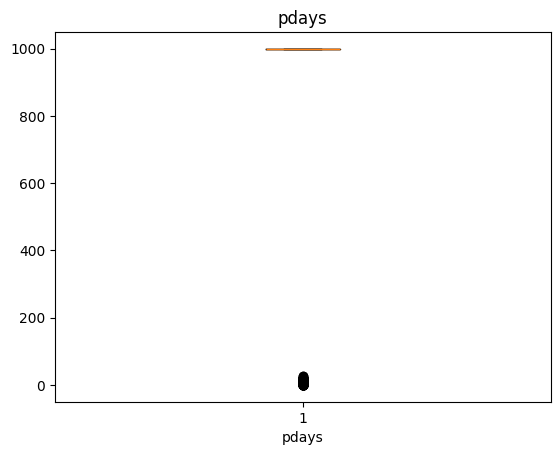

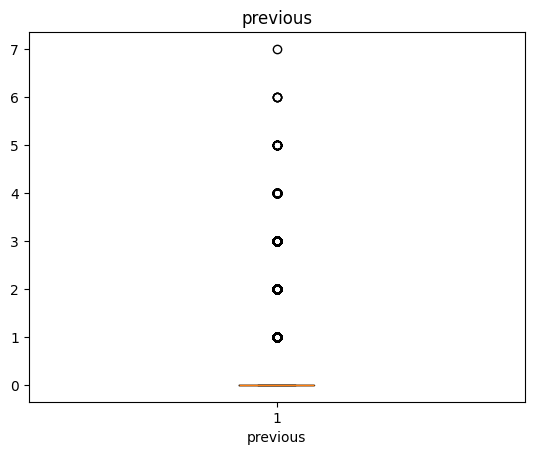

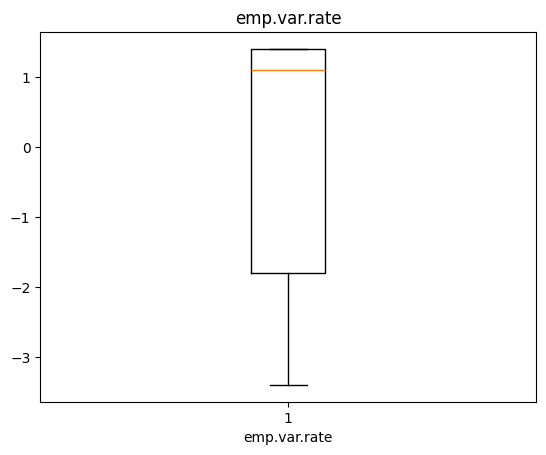

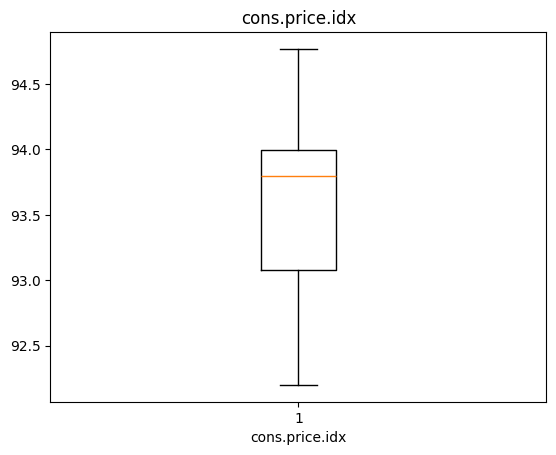

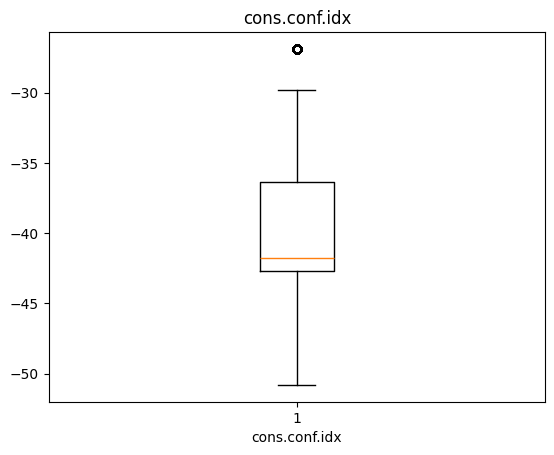

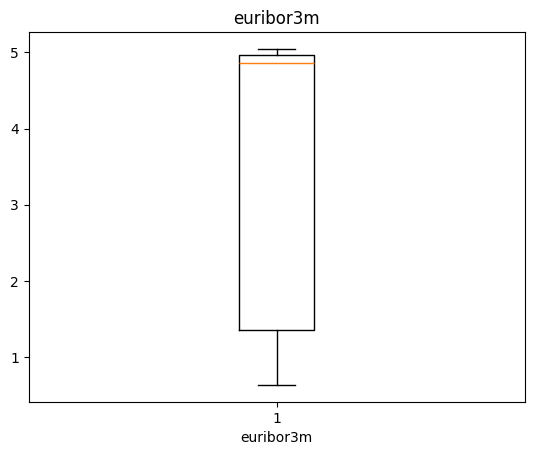

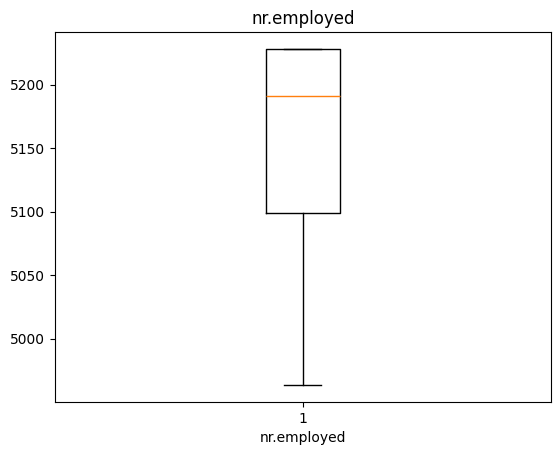

In [15]:
for col in df.columns:
    if df[col].dtype == "float64":     #df[i].dtypes=="int64" or df[i].dtypes=="float64"
        try:
            plt.boxplot(df[col].dropna())
            plt.title(col)
            plt.xlabel(col)
            plt.show()
        except Exception as e:
            print(f"Error in column: {col}")
            print(e)

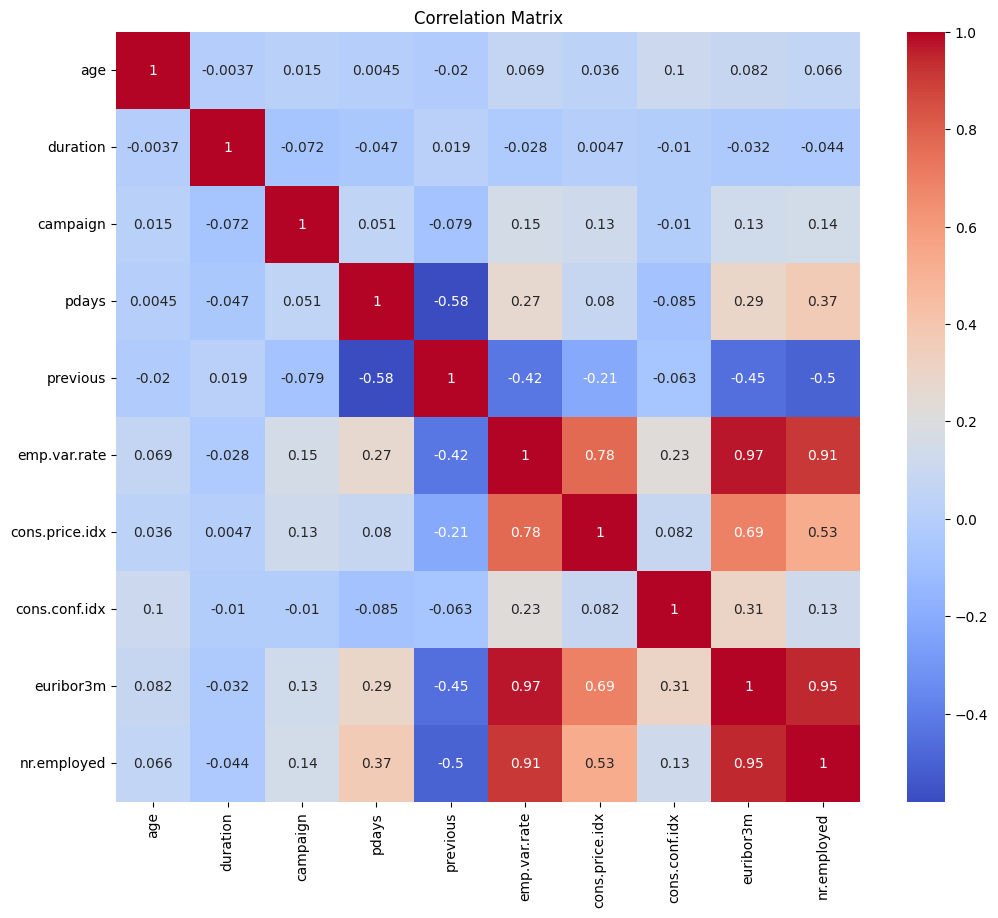

In [16]:
#Correlation
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12,10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

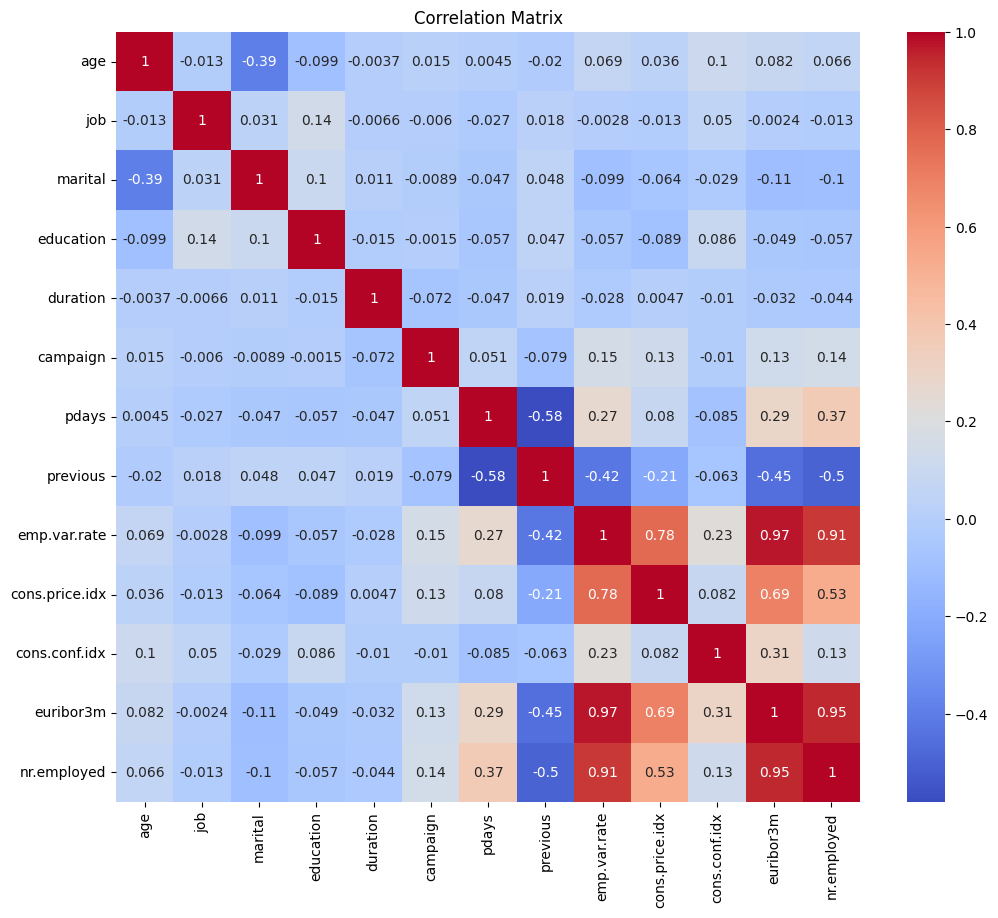

In [18]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [20]:
print(df.select_dtypes(include='object').columns)

Index(['default', 'housing', 'loan', 'contact', 'month', 'day_of_week',
       'poutcome', 'y'],
      dtype='str')


C:\Users\khush\AppData\Local\Temp\ipykernel_34136\2219242324.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include='object').columns)


In [21]:
#Label Encoding 
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode all object columns
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

C:\Users\khush\AppData\Local\Temp\ipykernel_34136\3303035241.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


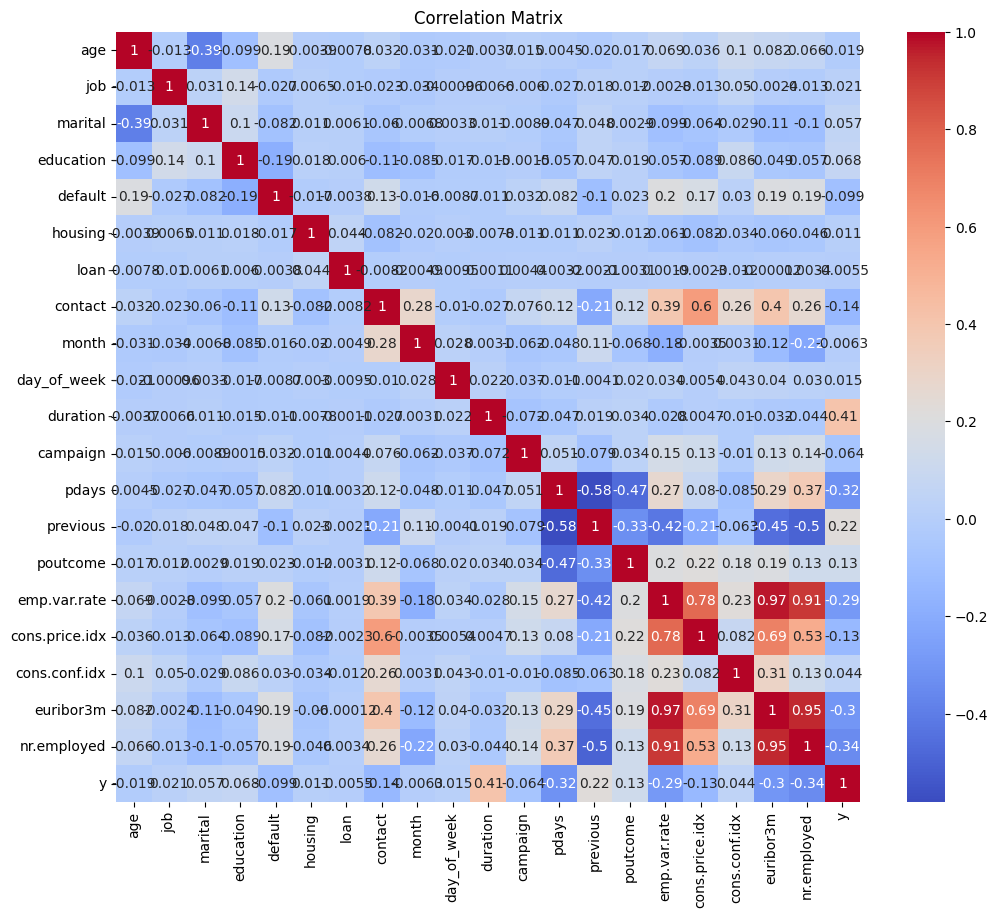

In [22]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

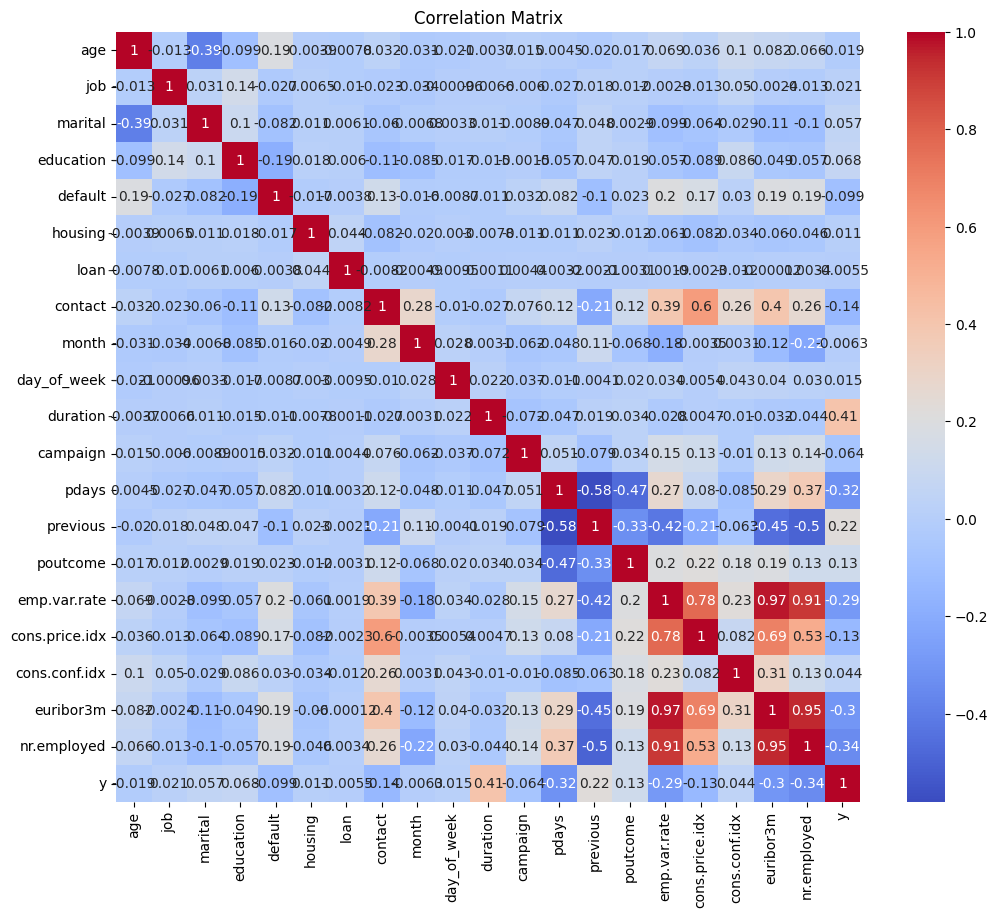

In [23]:
# StandardScaler()
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[df.columns] = scaler.fit_transform(df[df.columns])

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()
